# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 07: LARGE SUBSET ANALYSIS + STRUCTURED MODEL
# ============================================================
# Purpose:
# This notebook performs a large-subset confirmation experiment.
# It is designed to:
# 1. Profile the FMA large subset
# 2. Confirm scalability relative to small and medium
# 3. Train structured models on the large subset
# 4. Document class imbalance and modelling trade-offs
#
# Important:
# We use genre_top where available so that the prediction task
# remains comparable to earlier notebooks.
# ============================================================


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

tracks = pd.read_csv(
    "../data/raw/metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

print("Tracks shape:", tracks.shape)
print("Features shape:", features.shape)


Tracks shape: (106574, 52)
Features shape: (106574, 518)


In [3]:
# ============================================================
# 3. FILTER TO THE LARGE SUBSET
# ============================================================
# This is the large subset defined in tracks.csv.
# Note that this is still not the full FMA-Full audio archive.
# It is the large trimmed subset in the metadata definition.

subset_name = "large"

tracks_large = tracks[tracks[("set", "subset")] == subset_name]
features_large = features.loc[tracks_large.index]

print("\nLarge subset raw shape:")
print("Tracks large:", tracks_large.shape)
print("Features large:", features_large.shape)


Large subset raw shape:
Tracks large: (81574, 52)
Features large: (81574, 518)


In [4]:
# ============================================================
# 4. PROFILE THE LARGE SUBSET
# ============================================================
# We inspect:
# - split counts
# - missing genre_top values
# - available genre_top distribution
# - whether this subset is much more imbalanced than small/medium

print("\n===== LARGE SUBSET PROFILE =====")

split_counts_large = tracks_large[("set", "split")].value_counts(dropna=False)
print("\nSplit counts:")
print(split_counts_large)

missing_genre_top = tracks_large[("track", "genre_top")].isna().sum()
available_genre_top = tracks_large[("track", "genre_top")].notna().sum()

print("\nMissing genre_top:", missing_genre_top)
print("Available genre_top:", available_genre_top)

genre_counts_large = tracks_large[("track", "genre_top")].value_counts(dropna=True)

print("\nTop-level genre distribution (available labels only):")
print(genre_counts_large)



===== LARGE SUBSET PROFILE =====

Split counts:
(set, split)
training      64431
test           8690
validation     8453
Name: count, dtype: int64

Missing genre_top: 56976
Available genre_top: 24598

Top-level genre distribution (available labels only):
(track, genre_top)
Experimental           8357
Rock                   7079
Electronic             3058
Hip-Hop                1351
Folk                   1284
Pop                    1146
Instrumental            729
Classical               611
International           371
Spoken                  305
Jazz                    187
Old-Time / Historic      44
Blues                    36
Soul-RnB                 21
Country                  16
Easy Listening            3
Name: count, dtype: int64


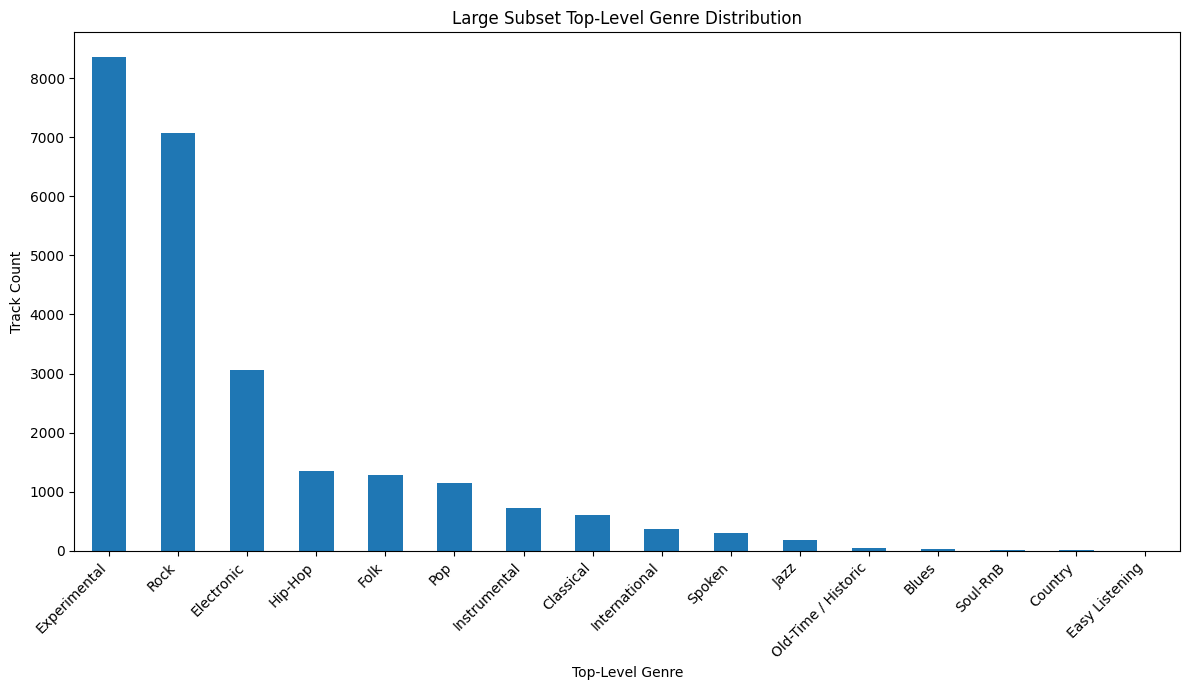

In [5]:
# ============================================================
# 5. VISUALIZE LARGE SUBSET GENRE DISTRIBUTION
# ============================================================
# This helps show class imbalance clearly.
# Expect much stronger imbalance than in small and medium.

plt.figure(figsize=(12, 7))
genre_counts_large.sort_values(ascending=False).plot(kind="bar")
plt.title("Large Subset Top-Level Genre Distribution")
plt.xlabel("Top-Level Genre")
plt.ylabel("Track Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 6. KEEP ONLY RECORDS WITH genre_top
# ============================================================
# To keep the task comparable to earlier notebooks, we only keep
# rows where genre_top exists.
# This means the large experiment is a structured confirmation
# model on the label-available portion of the large subset.

valid = tracks_large[("track", "genre_top")].notna()

tracks_large_valid = tracks_large[valid]
features_large_valid = features_large.loc[tracks_large_valid.index]

print("\nAfter filtering to rows with genre_top:")
print("Tracks:", tracks_large_valid.shape)
print("Features:", features_large_valid.shape)


After filtering to rows with genre_top:
Tracks: (24598, 52)
Features: (24598, 518)


In [7]:
# ============================================================
# 7. PREPARE X, y, AND split
# ============================================================
# We keep only numeric features and clean any problematic values.

X = features_large_valid.copy()
y = tracks_large_valid[("track", "genre_top")]
split = tracks_large_valid[("set", "split")]

X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("\nPrepared modelling data:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("split shape:", split.shape)



Prepared modelling data:
X shape: (24598, 518)
y shape: (24598,)
split shape: (24598,)


In [8]:
# ============================================================
# 8. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

X_train = X[split == "training"]
y_train = y[split == "training"]

X_val = X[split == "validation"]
y_val = y[split == "validation"]

X_test = X[split == "test"]
y_test = y[split == "test"]

print("\nTrain / Validation / Test shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Train / Validation / Test shapes:
X_train: (20021, 518)
y_train: (20021,)
X_val: (2199, 518)
y_val: (2199,)
X_test: (2378, 518)
y_test: (2378,)


In [9]:
# ============================================================
# 9. SCALE FEATURES FOR LINEAR SVM
# ============================================================
# Linear SVM is chosen here because it is more scalable than
# full kernel SVM for a larger dataset.
# This is intentional and should be explained in the report.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [10]:
# ============================================================
# 10. MODEL 0: LOGISTIC REGRESSION
# ============================================================
# Logistic Regression is added here as a lightweight linear
# baseline for the large subset.
# It is computationally cheaper than full kernel SVM and helps
# provide a three-model comparison on the large subset.

print("\n===== LARGE LOGISTIC REGRESSION =====")

lr_large = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_large.fit(X_train_scaled, y_train)

val_pred_lr = lr_large.predict(X_val_scaled)

print("Large Logistic Regression Validation Accuracy:",
      accuracy_score(y_val, val_pred_lr))

print(classification_report(y_val, val_pred_lr, zero_division=0))


===== LARGE LOGISTIC REGRESSION =====
Large Logistic Regression Validation Accuracy: 0.4874943155979991
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         1
          Classical       0.12      0.50      0.19        12
            Country       0.00      0.00      0.00         0
     Easy Listening       0.00      0.00      0.00         1
         Electronic       0.47      0.49      0.48       239
       Experimental       0.70      0.45      0.55       741
               Folk       0.31      0.65      0.42        77
            Hip-Hop       0.39      0.54      0.45        99
       Instrumental       0.10      0.25      0.14        60
      International       0.24      0.54      0.33        35
               Jazz       0.06      0.30      0.10        23
Old-Time / Historic       0.60      1.00      0.75         3
                Pop       0.25      0.23      0.24       191
               Rock       0.79      0.64

In [11]:
# ============================================================
# 11. MODEL 1: RANDOM FOREST
# ============================================================
# Random Forest is kept because:
# - it performs well on tabular data
# - it provides feature importance
# - it helps compare against previous notebooks

print("\n===== LARGE RANDOM FOREST =====")

rf_large = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_large.fit(X_train, y_train)

val_pred_rf = rf_large.predict(X_val)

print("Large Random Forest Validation Accuracy:",
      accuracy_score(y_val, val_pred_rf))

print(classification_report(y_val, val_pred_rf, zero_division=0))


===== LARGE RANDOM FOREST =====
Large Random Forest Validation Accuracy: 0.5734424738517508
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         1
          Classical       0.67      0.50      0.57        12
     Easy Listening       0.00      0.00      0.00         1
         Electronic       0.56      0.33      0.41       239
       Experimental       0.52      0.84      0.64       741
               Folk       0.65      0.48      0.55        77
            Hip-Hop       0.58      0.28      0.38        99
       Instrumental       0.00      0.00      0.00        60
      International       1.00      0.20      0.33        35
               Jazz       0.00      0.00      0.00        23
Old-Time / Historic       1.00      1.00      1.00         3
                Pop       0.00      0.00      0.00       191
               Rock       0.68      0.77      0.72       613
           Soul-RnB       0.00      0.00      0.00  

In [12]:
# ============================================================
# 12. MODEL 2: LINEAR SVM
# ============================================================
# We use LinearSVC instead of full RBF SVM because the large
# subset is more computationally demanding.
# class_weight='balanced' is included because imbalance is
# expected to be stronger here.

print("\n===== LARGE LINEAR SVM =====")

svm_large = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

svm_large.fit(X_train_scaled, y_train)

val_pred_svm = svm_large.predict(X_val_scaled)

print("Large Linear SVM Validation Accuracy:",
      accuracy_score(y_val, val_pred_svm))

print(classification_report(y_val, val_pred_svm, zero_division=0))



===== LARGE LINEAR SVM =====
Large Linear SVM Validation Accuracy: 0.5475216007276035
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         1
          Classical       0.16      0.50      0.24        12
            Country       0.00      0.00      0.00         0
     Easy Listening       0.00      0.00      0.00         1
         Electronic       0.55      0.51      0.53       239
       Experimental       0.68      0.56      0.62       741
               Folk       0.38      0.70      0.49        77
            Hip-Hop       0.38      0.60      0.46        99
       Instrumental       0.13      0.22      0.17        60
      International       0.31      0.60      0.41        35
               Jazz       0.09      0.39      0.15        23
Old-Time / Historic       0.30      1.00      0.46         3
                Pop       0.33      0.15      0.21       191
               Rock       0.76      0.72      0.74       6

c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
# ============================================================
# 13. MODEL COMPARISON SUMMARY (VALIDATION)
# ============================================================

large_results = pd.DataFrame({
    "Model": [
        "Large Logistic Regression",
        "Large Random Forest",
        "Large Linear SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_lr),
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm)
    ]
})

print("\nLarge Model Comparison:")
display(large_results)


Large Model Comparison:


,Model,Validation Accuracy
0,Large Logistic Regression,0.487494
1,Large Random Forest,0.573442
2,Large Linear SVM,0.547522


In [14]:
# ============================================================
# 13B. FINAL TEST: LARGE RANDOM FOREST
# ============================================================
# Random Forest had the best validation accuracy on the large subset,
# so it should also be evaluated on the test set.
# This allows us to compare the large-subset models fairly and
# choose the best large structured model based on validation results.

print("\n===== FINAL TEST: LARGE RANDOM FOREST =====")

test_pred_rf = rf_large.predict(X_test)

print("Large Random Forest Test Accuracy:",
      accuracy_score(y_test, test_pred_rf))

print(classification_report(y_test, test_pred_rf, zero_division=0))


===== FINAL TEST: LARGE RANDOM FOREST =====
Large Random Forest Test Accuracy: 0.6093355761143818
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         5
          Classical       0.00      0.00      0.00        25
         Electronic       0.52      0.28      0.36       207
       Experimental       0.56      0.85      0.67       860
               Folk       0.47      0.16      0.24       147
            Hip-Hop       0.75      0.54      0.63       103
       Instrumental       0.00      0.00      0.00       135
      International       1.00      0.04      0.07        26
               Jazz       0.00      0.00      0.00         8
Old-Time / Historic       1.00      0.50      0.67         4
                Pop       0.00      0.00      0.00        85
               Rock       0.71      0.77      0.74       753
           Soul-RnB       0.00      0.00      0.00         1
             Spoken       0.40      0.21      

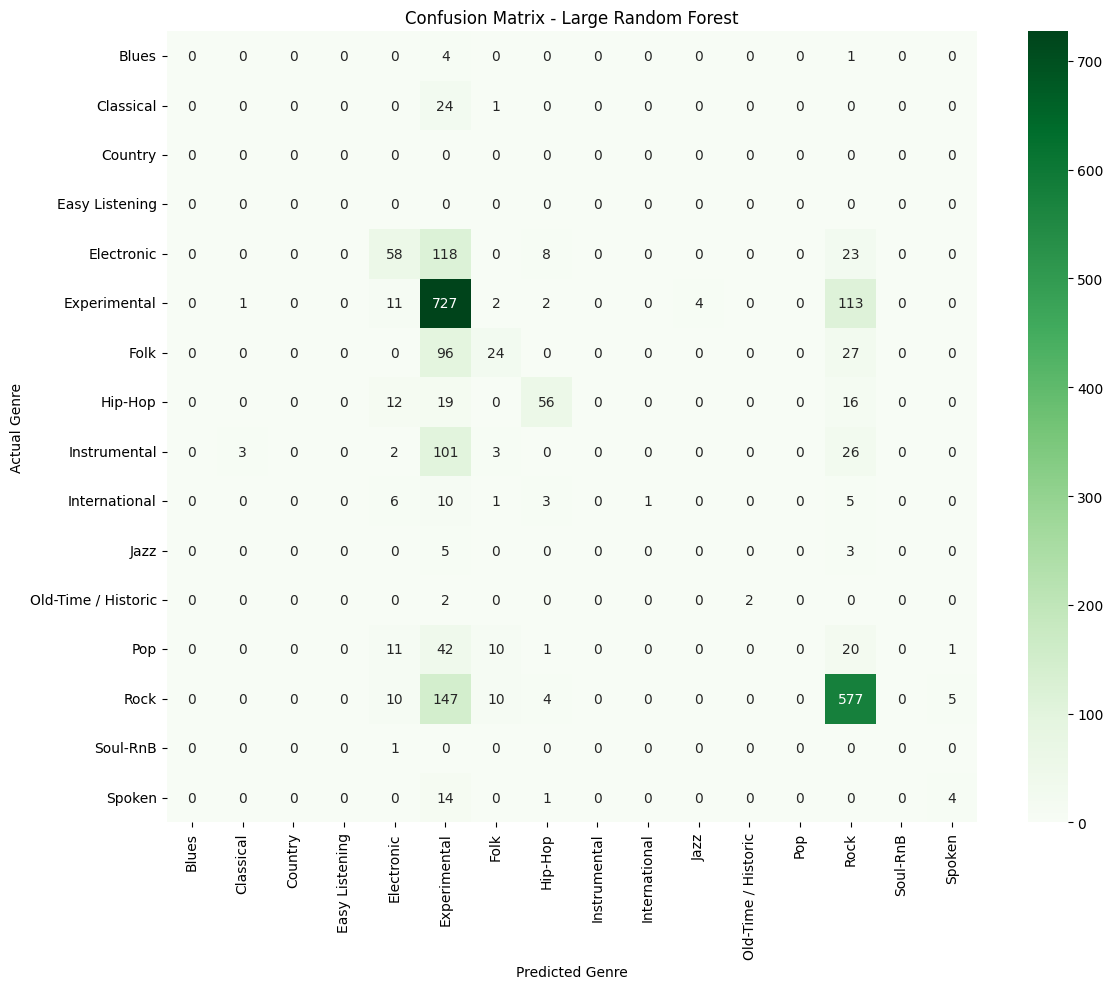

In [15]:
# ============================================================
# 13C. CONFUSION MATRIX - LARGE RANDOM FOREST
# ============================================================
# This confusion matrix shows how the Random Forest behaves
# on the large subset test data.

cm_rf = confusion_matrix(y_test, test_pred_rf, labels=rf_large.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_large.classes_,
    yticklabels=rf_large.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Large Random Forest")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 14. FINAL TEST EVALUATION
# ============================================================
# Select the better validation model.
# We default to Linear SVM here because it is the main scalable
# confirmation model for the large subset.

print("\n===== FINAL TEST: LARGE LINEAR SVM =====")

test_pred_svm = svm_large.predict(X_test_scaled)

print("Large Linear SVM Test Accuracy:",
      accuracy_score(y_test, test_pred_svm))

print(classification_report(y_test, test_pred_svm, zero_division=0))


===== FINAL TEST: LARGE LINEAR SVM =====
Large Linear SVM Test Accuracy: 0.5294365012615644
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         5
          Classical       0.22      0.44      0.29        25
            Country       0.00      0.00      0.00         0
     Easy Listening       0.00      0.00      0.00         0
         Electronic       0.38      0.39      0.39       207
       Experimental       0.75      0.53      0.62       860
               Folk       0.30      0.33      0.31       147
            Hip-Hop       0.51      0.87      0.64       103
       Instrumental       0.16      0.10      0.12       135
      International       0.16      0.46      0.24        26
               Jazz       0.01      0.12      0.02         8
Old-Time / Historic       0.67      1.00      0.80         4
                Pop       0.01      0.02      0.02        85
               Rock       0.76      0.71      0.73  

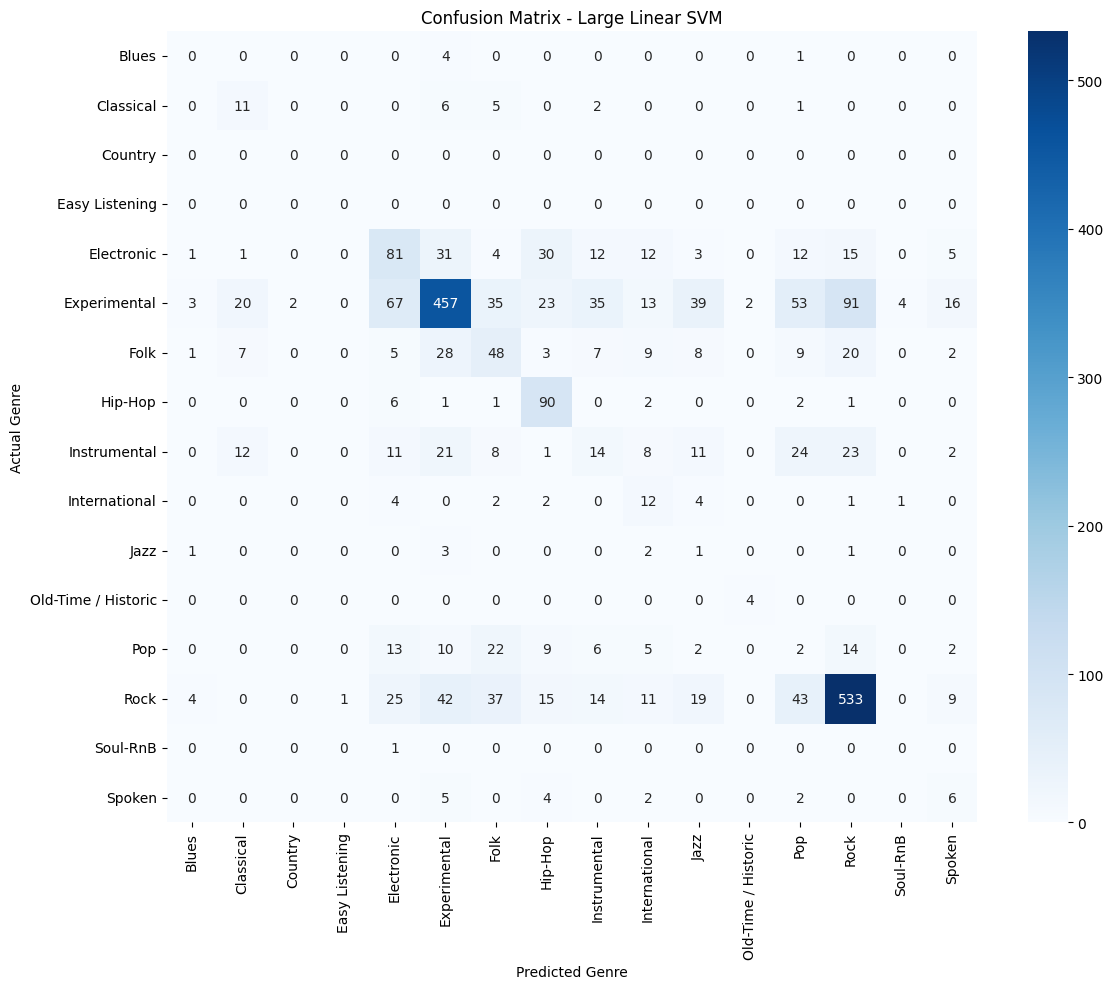

In [17]:

# ============================================================
# 15. CONFUSION MATRIX
# ============================================================
# This shows how the model behaves across the large subset's
# top-level genres.

cm = confusion_matrix(y_test, test_pred_svm, labels=svm_large.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_large.classes_,
    yticklabels=svm_large.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Large Linear SVM")
plt.tight_layout()
plt.show()


Top 20 Important Features - Large Random Forest:
feature            statistics  number
mfcc               max         04        0.008238
spectral_contrast  median      04        0.006174
mfcc               max         01        0.006100
rmse               median      01        0.005992
chroma_cens        max         10        0.005958
rmse               max         01        0.005856
spectral_contrast  min         03        0.005824
                   mean        04        0.005814
mfcc               median      07        0.005416
rmse               std         01        0.005301
mfcc               max         03        0.005276
rmse               mean        01        0.005174
mfcc               mean        01        0.005046
                               04        0.004827
                               07        0.004800
tonnetz            std         06        0.004748
mfcc               max         07        0.004675
                               13        0.004647
            

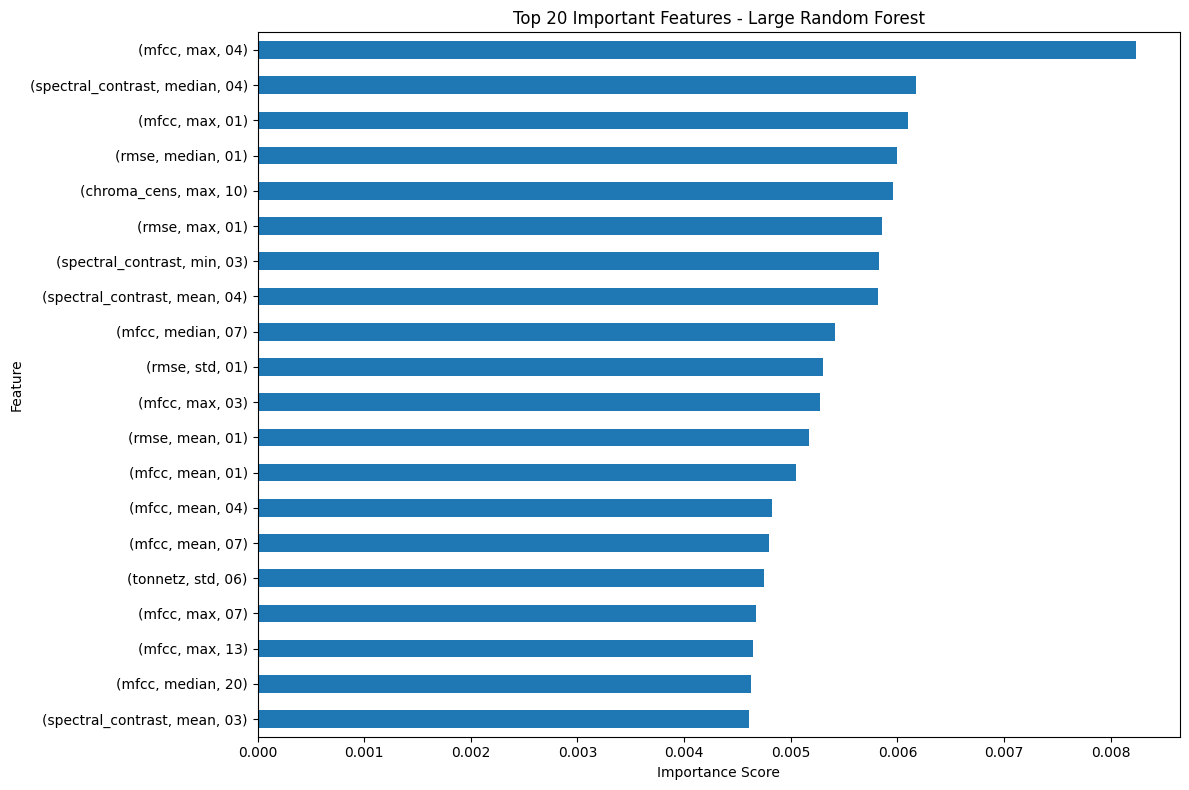

In [18]:

# ============================================================
# 16. FEATURE IMPORTANCE FROM LARGE RANDOM FOREST
# ============================================================
# Linear SVM is used for scalable confirmation.
# Random Forest is used to interpret feature importance.

feature_importance = pd.Series(
    rf_large.feature_importances_,
    index=X.columns
)

top_features = feature_importance.sort_values(ascending=False).head(20)

print("\nTop 20 Important Features - Large Random Forest:")
print(top_features)

plt.figure(figsize=(12, 8))
top_features.sort_values().plot(kind="barh")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - Large Random Forest")
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 16. CROSS-SUBSET PERFORMANCE SUMMARY
# ============================================================
# This table summarizes the best structured model chosen at each stage.
# For the large subset, Random Forest is used because it achieved the
# highest validation accuracy among the large-subset models.

summary_results = pd.DataFrame({
    "Subset": [
        "Small",
        "Medium",
        "Large"
    ],
    "Best Structured Model": [
        "Improved SVM",
        "Balanced SVM",
        "Large Random Forest"
    ],
    "Validation Accuracy": [
        0.5575,                         # Small best validation
        0.7442815249266862,             # Medium balanced SVM validation
        accuracy_score(y_val, val_pred_rf)
    ],
    "Test Accuracy": [
        0.46375,                        # Small final test
        0.7225042301184433,             # Medium balanced SVM test
        accuracy_score(y_test, test_pred_rf)
    ]
})

print("\nCross-Subset Structured Comparison:")
display(summary_results)


Cross-Subset Structured Comparison:


,Subset,Best Structured Model,Validation Accuracy,Test Accuracy
0,Small,Improved SVM,0.557500,0.463750
1,Medium,Balanced SVM,0.744282,0.722504
2,Large,Large Random Forest,0.573442,0.609336


In [20]:
# ============================================================
# 18. INTERPRETATION NOTES
# ============================================================
# This cell prints key interpretation points that can later be
# copied into the report.

print("\n===== INTERPRETATION NOTES =====")
print("1. Small subset was used for rapid prototyping and debugging.")
print("2. Medium subset demonstrated strong performance gains with more data.")
print("3. Large subset is used here as a confirmation experiment aligned with the approved proposal.")
print("4. The large subset is expected to expose stronger class imbalance than small/medium.")
print("5. Linear SVM was included as a scalable large-subset comparison model instead of full kernel SVM.")
print("6. Random Forest was retained for interpretability and achieved the best validation performance on the large subset.")
print("7. The large subset confirms proposal-scale relevance, but also exposes missing-label and class-imbalance limitations.")


===== INTERPRETATION NOTES =====
1. Small subset was used for rapid prototyping and debugging.
2. Medium subset demonstrated strong performance gains with more data.
3. Large subset is used here as a confirmation experiment aligned with the approved proposal.
4. The large subset is expected to expose stronger class imbalance than small/medium.
5. Linear SVM was included as a scalable large-subset comparison model instead of full kernel SVM.
6. Random Forest was retained for interpretability and achieved the best validation performance on the large subset.
7. The large subset confirms proposal-scale relevance, but also exposes missing-label and class-imbalance limitations.
